# Pausa práctica 3 — QAOA resolviendo Max-Cut en vivo

**Contexto:** acabamos de ver QAOA, VQE, Annealing, Gate-based y su comparación. Ahora resolvemos un problema de optimización combinatoria real con QAOA: **Max-Cut** sobre un grafo pequeño.

**El problema:** dado un grafo, dividir los nodos en 2 grupos para maximizar el número de aristas "cortadas" entre grupos. Es NP-hard, el mismo tipo de dificultad que logística, portafolios o scheduling.

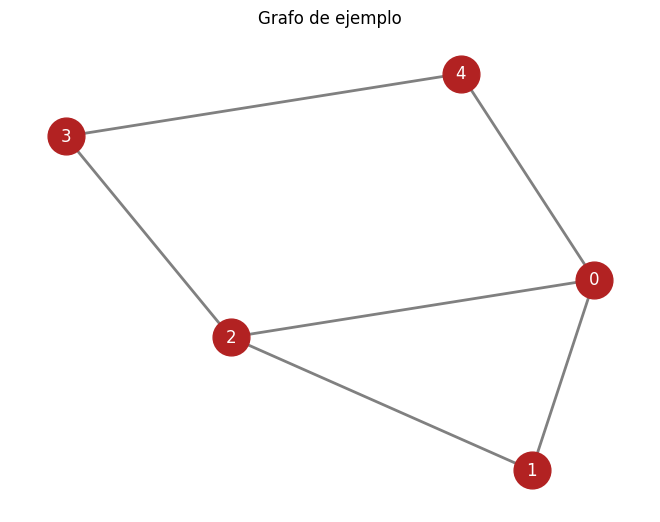

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Grafo de ejemplo (5 nodos) — dibújalo también en la pizarra antes de correr esto
G = nx.Graph()
G.add_weighted_edges_from([
    (0, 1, 1.0), (1, 2, 1.0), (2, 3, 1.0),
    (3, 4, 1.0), (4, 0, 1.0), (0, 2, 1.0)
])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="#B22222", font_color="white",
        node_size=700, width=2, edge_color="gray")
plt.title("Grafo de ejemplo")
plt.savefig("grafo_maxcut.png", dpi=140, bbox_inches="tight")
plt.show()


## Formulación QUBO

Convertimos Max-Cut al mismo formato QUBO que vimos en la diapositiva de Quantum Annealing.

In [6]:
%pip install qiskit-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 26.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 19.2 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=a607c7821ce4c0b4bedc3817910f8508e8a061406e7aadf7e0954403b3b74571
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex


In [7]:
from qiskit_optimization.applications import Maxcut

maxcut = Maxcut(G)
qp = maxcut.to_quadratic_program()
print(qp.prettyprint())


Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_2 - 2*x_0*x_4 - 2*x_1*x_2 - 2*x_2*x_3 - 2*x_3*x_4 + 3*x_0
  + 2*x_1 + 3*x_2 + 2*x_3 + 2*x_4

Subject to
  No constraints

  Binary variables (5)
    x_0 x_1 x_2 x_3 x_4



## Resolviendo con QAOA

In [9]:
%pip install qiskit-algorithms qiskit-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 18.6 MB/s eta 0:00:00


In [10]:
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer

sampler = Sampler()
qaoa = QAOA(sampler=sampler, optimizer=COBYLA(maxiter=100), reps=2)
qaoa_optimizer = MinimumEigenOptimizer(qaoa)

result = qaoa_optimizer.solve(qp)
print(result)


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


fval=5.0, x_0=0.0, x_1=0.0, x_2=1.0, x_3=0.0, x_4=1.0, status=SUCCESS


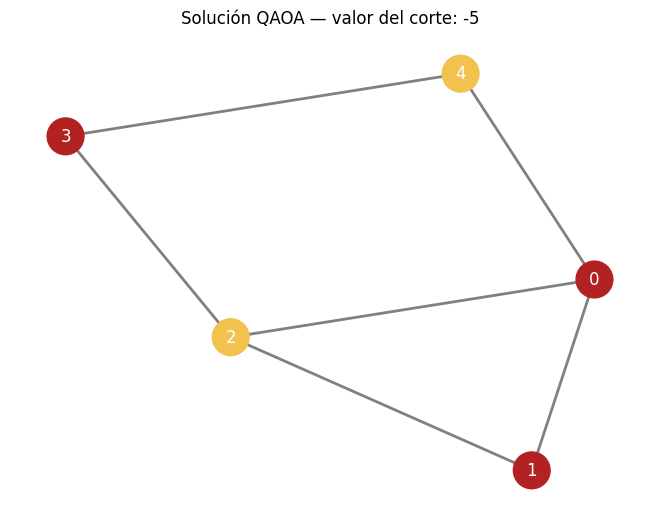


Asignación de grupos: [0. 0. 1. 0. 1.]
Valor del corte (edges cortados): -5


In [11]:
# Visualizar la solución encontrada
solution = result.x
colors = ["#B22222" if solution[i] == 0 else "#F2C14E" for i in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=colors, font_color="white",
        node_size=700, width=2, edge_color="gray")
plt.title(f"Solución QAOA — valor del corte: {int(-result.fval)}")
plt.savefig("solucion_maxcut.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"\nAsignación de grupos: {solution}")
print(f"Valor del corte (edges cortados): {int(-result.fval)}")


¿Adivinaron el número de corte?. El punto es que este mismo enfoque (QUBO + QAOA) escala al mismo patrón que logística (VRP), portafolios y scheduling que vimos en el bloque anterior — la única diferencia es el tamaño del grafo.